This code is for the training and testing of the DQL agents. At the bottom, we have prepared the model intended for final testing, and we have already set a time limit of 3600 seconds or an episode limit of 1000000 episodes. The rest of the code does not need to be run.

Import

In [1]:
from flappy_agent_DQL import *
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\arnar\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.13.5)
Hello from the pygame community. https://www.pygame.org/contribute.html
couldn't import doomish
Couldn't import doom


Initial agent: alpha = 0.1, epsilon = 0.1 with no decay, copy update

In [2]:
initial_agent = FlappyAgent()
nb_episodes = 1000000
train(nb_episodes, initial_agent, time_limit=1800, learning_curve=True)

Flappy Agent Initialized
Doing Deep Q Learning with:
    Alpha: 0.001
    Epsilon decay: False, Epsilon: 0.1
    Soft update: False
Episode 100 completed
Episode 200 completed
Episode 300 completed
Episode 400 completed
Episode 500 completed
Episode 600 completed
Episode 700 completed
Episode 800 completed
Episode 900 completed
Episode 1000 completed


KeyboardInterrupt: 

In [11]:
run_game(100,initial_agent,display_screen=True,force_fps=False)

SystemExit: 

C:\Users\arnar\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Alpha = 0.01

In [12]:
alpha_agent = FlappyAgent(alpha=0.01)
nb_episodes = 1000000
train(nb_episodes, alpha_agent, time_limit=1800)

Flappy Agent Initialized
Doing Deep Q Learning with:
    Alpha: 0.01
    Epsilon decay: False, Epsilon: 0.1
    Soft update: False
Episode 100 completed
Episode 200 completed
Episode 300 completed


KeyboardInterrupt: 

In [14]:
run_game(1,alpha_agent,display_screen=True,force_fps=False)

SystemExit: 

Epsilon decay

In [ ]:
decay_agent = FlappyAgent(alpha=0.01,epsilon_decay=[True, 1.0, 0.9999, 0.1])
nb_episodes = 1000000
train(nb_episodes, decay_agent, time_limit=1800,learning_curve=True)

Flappy Agent Initialized
Doing Deep Q Learning with:
    Alpha: 0.01
    Epsilon decay: True, Epsilon: 1.0, Min epsilon: 0.1, Epsilon decay rate: 0.9999
    Soft update: False
Episode 100 completed
Episode 200 completed
Episode 300 completed
Episode 400 completed
Episode 500 completed
Episode 600 completed
Episode 700 completed
Episode 800 completed
Episode 900 completed
Episode 1000 completed
Episode 1100 completed
Episode 1200 completed
Episode 1300 completed
Episode 1400 completed
Episode 1500 completed
Episode 1600 completed
Episode 1700 completed


Soft update

In [ ]:
update_agent = FlappyAgent(alpha=0.01,soft_update=[True, 0.01])
nb_episodes = 1000000
train(nb_episodes, update_agent, time_limit=1800,learning_curve=True)

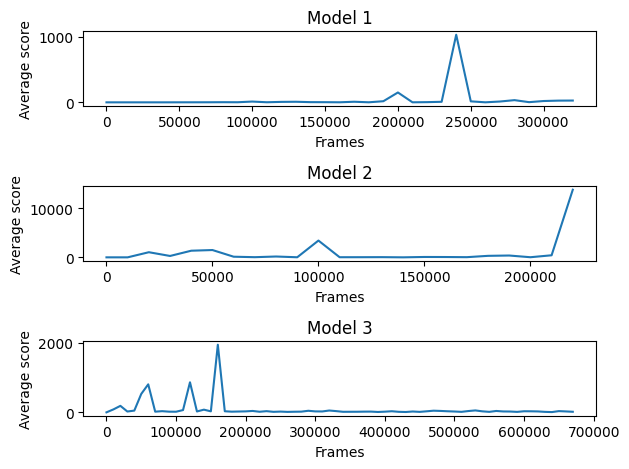

In [ ]:
lc1 = initial_agent.learning_curve
lc2 = alpha_agent.learning_curve
lc3 = decay_agent.learning_curve
plt.subplot(3,1,1)
plt.plot([i*10000 for i in range(len(lc1))], lc1)
plt.xlabel('Frames')
plt.ylabel('Average score')
plt.title('Model 1')
plt.subplot(3,1,2)
plt.plot([i*10000 for i in range(len(lc2))], lc2)
plt.xlabel('Frames')
plt.ylabel('Average score')
plt.title('Model 2')
plt.subplot(3,1,3)
plt.plot([i*10000 for i in range(len(lc3))], lc3)
plt.xlabel('Frames')
plt.ylabel('Average score')
plt.title('Model 3')
plt.tight_layout()
plt.show()

In [ ]:
run_game(10,initial_agent)
print('Model 1 done')
run_game(10,alpha_agent)
print('Model 2 done')
run_game(10,decay_agent)
print('Model 3 done')

Model 1 done


KeyboardInterrupt: 

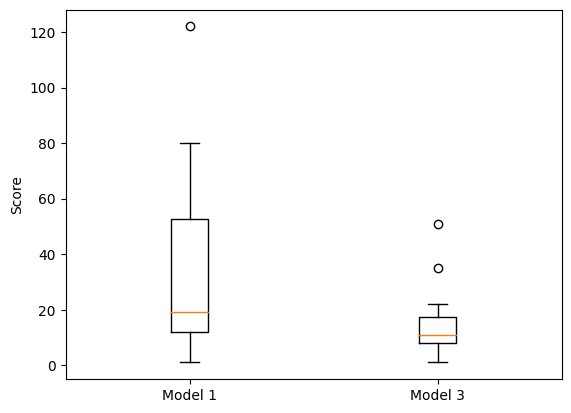

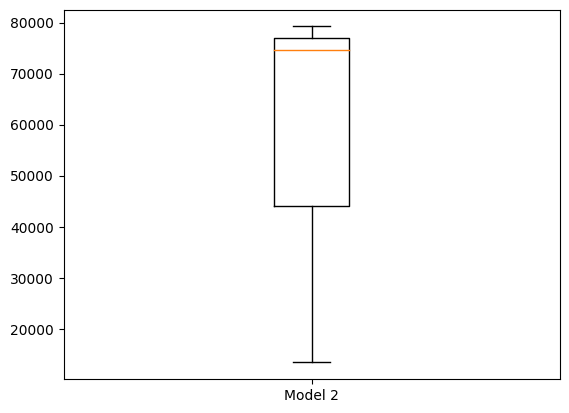

Model 1
 Average score:  37.09090909090909
 Standard deviation:  35.81887401269323
 Best score:  122.0
 Worst score:  1.0
Model 2
 Average score:  55733.666666666664
 Standard deviation:  30001.26985460597
 Best score:  79237.0
 Worst score:  13391.0
Model 3
 Average score:  16.272727272727273
 Standard deviation:  13.91592226774724
 Best score:  51.0
 Worst score:  1.0


In [ ]:
fig, ax = plt.subplots()
ax.boxplot([initial_agent.test_scores, decay_agent.test_scores])
ax.set_xticklabels(['Model 1', 'Model 3'])
plt.ylabel('Score')
plt.show()
fig, ax = plt.subplots()
ax.boxplot([alpha_agent.test_scores])
ax.set_xticklabels(['Model 2'])
plt.show()

print('Model 1')
print(' Average score: ', np.mean(initial_agent.test_scores))
print(' Standard deviation: ', np.std(initial_agent.test_scores))
print(' Best score: ', np.max(initial_agent.test_scores))
print(' Worst score: ', np.min(initial_agent.test_scores))
print('Model 2')
print(' Average score: ', np.mean(alpha_agent.test_scores))
print(' Standard deviation: ', np.std(alpha_agent.test_scores))
print(' Best score: ', np.max(alpha_agent.test_scores))
print(' Worst score: ', np.min(alpha_agent.test_scores))
print('Model 3')
print(' Average score: ', np.mean(decay_agent.test_scores))
print(' Standard deviation: ', np.std(decay_agent.test_scores))
print(' Best score: ', np.max(decay_agent.test_scores))
print(' Worst score: ', np.min(decay_agent.test_scores))

Final test

In [ ]:
from flappy_agent_DQL import *

pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
couldn't import doomish
Couldn't import doom


In [ ]:
agent = FlappyAgent(alpha=0.01)
nb_episodes = 1000000
train(nb_episodes, agent, time_limit=3600)

Flappy Agent Initialized
Doing Deep Q Learning with:
    Alpha: 0.01
    Epsilon decay: False, Epsilon: 0.1
    Soft update: False
Episode 100 completed


SystemExit: 

In [ ]:
run_game(100,agent)

In [ ]:
scores = agent.test_scores
print(f'Average score: {np.mean(scores)} with standard deviation: {np.std(scores)}')
print(f'Max score: {np.max(scores)}')
print(f'Min score: {np.min(scores)}')

In [ ]:
run_game(100,agent,display_screen=True,force_fps=False)

SystemExit: 

In [ ]:
agent = FlappyAgent(alpha=0.01)
train(1000, agent, time_limit=3600)

Flappy Agent Initialized
Doing Deep Q Learning with:
    Alpha: 0.01
    Epsilon decay: False, Epsilon: 0.1
    Soft update: False
Episode 100 completed


KeyboardInterrupt: 

In [ ]:
run_game(100,agent,display_screen=True,force_fps=False)

SystemExit: 

C:\Users\arnar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\interactiveshell.py:3534: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
